<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install xgboost catboost optuna lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 20.4 MB/s eta 0:00:00


In [4]:
!pip install optuna

In [5]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 13.5 MB/s eta 0:00:00


In [6]:
import glob
import os
import re
import matplotlib.pyplot as plt
import pandas as pd

# 1. 実行中のディレクトリ（または特定のフォルダ）内から 'result_' で始まるCSVファイルを自動検索
# ※スクリプトと同じフォルダにあるファイルを対象にする場合はこれで動作します
csv_files = glob.glob("result_*.csv")

data = []
# ファイル名から「番号」「ACU」「Loss」を抽出する正規表現パターン
pattern = r"result_(\d+)\(ACU([\d\.]+),Loss([\d\.]+)\)\.csv"

# 2. 自動取得したファイル群から情報を抽出
for f in csv_files:
    # パス（フォルダ名など）が含まれている場合を考慮し、純粋なファイル名のみを抽出
    basename = os.path.basename(f)

    match = re.match(pattern, basename)
    if match:
        num = int(match.group(1))
        acu = float(match.group(2))
        loss = float(match.group(3))
        data.append({"result_num": num, "ACU": acu, "Loss": loss})

# データが1つも見つからなかった場合の処理
if not data:
    print(
        "条件（result_数字(ACU...,Loss...).csv）に一致するファイルが見つかりませんでした。"
    )
else:
    # 3. データを結果の番号順（1, 2, 3...）に並び替えてDataFrameに変換
    df_metrics = pd.DataFrame(data).sort_values(by="result_num").reset_index(drop=True)

    # 4. 散布図のプロット
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        df_metrics["ACU"],
        df_metrics["Loss"],
        color="crimson",
        s=100,
        edgecolors="black",
        alpha=0.8,
        label="Results",
    )

    # 各プロット点に対応する結果番号を注釈として自動追加
    for i, txt in enumerate(df_metrics["result_num"]):
        ax.annotate(
            f"result_{txt}",
            (df_metrics["ACU"].iloc[i], df_metrics["Loss"].iloc[i]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=9,
            fontweight="bold",
        )

    # 軸ラベルとタイトルの設定
    ax.set_xlabel("ACU", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title(
        "Distribution of ACU vs Loss (Auto-loaded)", fontsize=14, fontweight="bold"
    )
    ax.grid(True, linestyle="--", alpha=0.6)

    # レイアウトの自動調整
    plt.tight_layout()

    # 5. 画像の保存
    output_image = "acu_loss_distribution_auto.png"
    plt.savefig(output_image, dpi=300)
    print(
        f"全 {len(df_metrics)} 個のファイルを自動認識し、散布図を '{output_image}' として保存しました。"
    )

条件（result_数字(ACU...,Loss...).csv）に一致するファイルが見つかりませんでした。


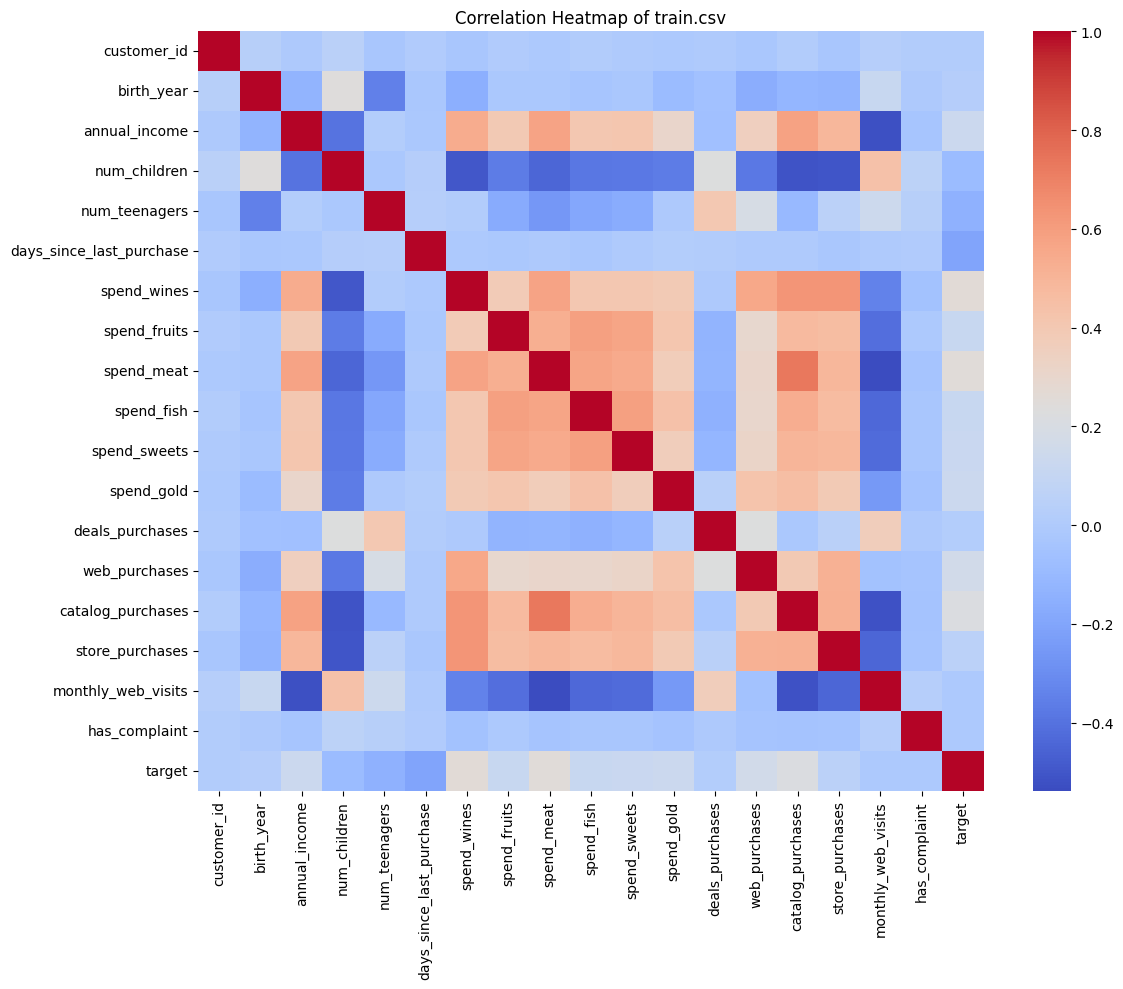

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# データの読み込み
df = pd.read_csv('train.csv')

# 数値型の列のみを抽出（文字列や日付データを除外）
numeric_df = df.select_dtypes(include=['number'])

# 相関行列の計算
corr = numeric_df.corr()

# ヒートマップの作成
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of train.csv')
plt.tight_layout()

# 画像として保存
plt.savefig('heatmap.png')

In [8]:
import pandas as pd
import numpy as np
import warnings
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss
from lightgbm import LGBMClassifier, early_stopping
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ==========================================
# 0. 絶対にリークしない事前処理（行単位の処理）
# ==========================================
def preprocess_safe_row_wise(df):
    """
    他行のデータに依存しない処理（特徴量追加など）を適用。
    分析インサイトに基づいたドメイン知識を特徴量として明示的に追加。
    """
    df = df.copy()

    # --- 1. 日付・年齢に関する特徴量（インサイト：30代前後と40代以降で顕著な差） ---
    base_date = pd.to_datetime('2015-01-01')
    if 'registration_date' in df.columns:
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        df = df.drop('registration_date', axis=1)

    # 仮に年齢(age)の列がある場合、あるいは登録期間から類推する場合のインサイト反映
    if 'age' in df.columns:
        # 20代後半〜30代後半 (Target 1 が優勢なゾーン)
        df['prime_young_age_flag'] = ((df['age'] >= 25) & (df['age'] <= 39)).astype(int)
        # 55歳〜60歳付近 (Target 0 の第2のピーク)
        df['older_peak_flag'] = ((df['age'] >= 55) & (df['age'] <= 60)).astype(int)

    # --- 2. 年収に関する特徴量（インサイト：70,000ドルでの逆転現象） ---
    if 'annual_income' in df.columns:
        df['high_income_th'] = (df['annual_income'] >= 70000).astype(int)
        df['middle_income_cluster'] = ((df['annual_income'] >= 30000) & (df['annual_income'] <= 65000)).astype(int)

    # --- 3. 支出に関する特徴量（インサイト：ワイン600以上、肉200以上でTarget 1が急増） ---
    if 'spend_wines' in df.columns:
        df['wine_heavy_spender'] = (df['spend_wines'] >= 600).astype(int)
    if 'spend_meat' in df.columns:
        df['meat_heavy_spender'] = (df['spend_meat'] >= 200).astype(int)

    # --- 4. マーケティング理論・相関分析に基づく高度特徴量 ---
    # 客単価 (AOV) と 購買集中度 (HHI)
    if all(c in df.columns for c in ['store_purchases', 'web_purchases', 'catalog_purchases',
                                     'spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold']):
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        total_spend = df['spend_wines'] + df['spend_fruits'] + df['spend_meat'] + df['spend_fish'] + df['spend_sweets'] + df['spend_gold']

        df['average_order_value'] = total_spend / (total_purchases + 1)

        # カテゴリ集中度 (HHI)
        for cat in ['spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold']:
            df[f'{cat}_share'] = df[cat] / (total_spend + 1)

        df['hhi_category_concentration'] = (
            df['spend_wines_share']**2 + df['spend_fruits_share']**2 + df['spend_meat_share']**2 +
            df['spend_fish_share']**2 + df['spend_sweets_share']**2 + df['spend_gold_share']**2
        )

    # インサイト：Web訪問回数が多く、全体の支出が低いが割引を狙う層
    if all(c in df.columns for c in ['monthly_web_visits', 'deals_purchases']):
        df['web_discount_hunter_idx'] = df['monthly_web_visits'] * df['deals_purchases']

    return df

# ==========================================
# 0.5 カテゴリ変数の型変換（LightGBMネイティブ対応用）
# ==========================================
def convert_categorical_types(df, cat_cols):
    """ 指定された列をPandasのcategory型に変換する """
    df = df.copy()
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')
    return df

# ==========================================
# 1. Optuna (パラメータチューニング)
# ==========================================
def tune_lightgbm_with_optuna(X_raw, y, cat_cols, n_trials=15):
    print("\n--- [1. Optuna パラメータ最適化 (LightGBM カテゴリカル対応)] ---")

    def objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 500,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'class_weight': 'balanced',
            'verbose': -1
        }

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            # 欠損値処理（年収のメディアン補完）
            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            # 型を明示的にcategory化（LightGBMのネイティブ機能に必要）
            X_tr = convert_categorical_types(X_tr, cat_cols)
            X_va = convert_categorical_types(X_va, cat_cols)

            model = LGBMClassifier(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[early_stopping(stopping_rounds=30, verbose=False)]
            )

            oof[va_idx] = model.predict_proba(X_va)[:, 1]

        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_params.update({'random_state': 42, 'n_estimators': 1000, 'class_weight': 'balanced', 'verbose': -1})
    return best_params

# ==========================================
# 2. 学習フェーズ (Train & Validate)
# ==========================================
def train_models(X_raw, y, lgb_best_params, cat_cols, seeds=[42, 2023, 777], n_splits=5):
    print(f"\n--- [2. 学習フェーズ開始 (LightGBM 単体・シードアンサンブル)] ---")

    artifacts = []
    oof_preds_ensemble = np.zeros(len(X_raw))

    for seed in seeds:
        print(f">> Running Seed: {seed}...")
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof_seed = np.zeros(len(X_raw))

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y)):
            X_tr, y_tr = X_raw.iloc[train_idx].copy(), y.iloc[train_idx]
            X_va, y_va = X_raw.iloc[val_idx].copy(), y.iloc[val_idx]

            # 補完処理
            income_median = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(income_median)
            X_va['annual_income'] = X_va['annual_income'].fillna(income_median)

            # カテゴリ列をcategory型に変換 (決定木エンコーダは不要に)
            X_tr = convert_categorical_types(X_tr, cat_cols)
            X_va = convert_categorical_types(X_va, cat_cols)

            lgb_params = lgb_best_params.copy()
            lgb_params['random_state'] = seed

            # 単一アルゴリズム(LightGBM)のパラメータ違いやシード違いをアンサンブル
            model = LGBMClassifier(**lgb_params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[early_stopping(stopping_rounds=30, verbose=False)]
            )

            oof_seed[val_idx] = model.predict_proba(X_va)[:, 1]

            artifacts.append({
                'seed': seed,
                'fold': fold,
                'preprocessors': {
                    'income_median': income_median,
                    'cat_cols': cat_cols
                },
                'model': model,
                'feature_names': list(X_tr.columns) # 💡 列順を完全に記憶
            })

        oof_preds_ensemble += oof_seed / len(seeds)

    final_cv_score = roc_auc_score(y, oof_preds_ensemble)
    final_cv_loss = log_loss(y, oof_preds_ensemble)
    print(f"✅ 学習完了: 最終 OOF AUC (CVスコア): {final_cv_score:.4f} / 最終 Log Loss: {final_cv_loss:.4f}")

    return artifacts, oof_preds_ensemble

# ==========================================
# 3. 予測フェーズ (Predict)
# ==========================================
def predict_models(X_test_raw, artifacts):
    print("\n--- [3. 予測フェーズ開始] ---")
    final_test_preds = np.zeros(len(X_test_raw))
    total_models = 0

    for artifact in artifacts:
        X_te = X_test_raw.copy()
        preps = artifact['preprocessors']
        model = artifact['model']

        # 学習時と同じルールで補完・型変換
        X_te['annual_income'] = X_te['annual_income'].fillna(preps['income_median'])
        X_te = convert_categorical_types(X_te, preps['cat_cols'])

        # 💡重要：学習時と『全く同じ列の並び順』に強制的に揃える（エラー防止）
        X_te = X_te[artifact['feature_names']]

        final_test_preds += model.predict_proba(X_te)[:, 1]
        total_models += 1

    final_test_preds /= total_models
    print(f"✅ 予測完了: 計 {total_models} 個のモデルによるアンサンブル予測を実行しました。")
    return final_test_preds

# ==========================================
# メイン実行ブロック
# ==========================================
if __name__ == "__main__":
    # データの読み込み (実際の環境に合わせてパスを変更してください)
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    # ネイティブ対応させるカテゴリ変数の定義
    categorical_columns = ['education_level', 'marital_status']

    # ① 安全な特徴量エンジニアリングの実行
    train_df = preprocess_safe_row_wise(train_data)
    test_df = preprocess_safe_row_wise(test_data)

    X_raw = train_df.drop(['customer_id', 'target'], axis=1, errors='ignore')
    y = train_df['target']
    X_test_raw = test_df.drop(['customer_id'], axis=1, errors='ignore')

    # ② LightGBM専用のパラメータ最適化
    best_lgb_params = tune_lightgbm_with_optuna(X_raw, y, categorical_columns, n_trials=10)

    # ③ 【学習フェーズ】カテゴリカル対応モデルの訓練
    artifacts, oof_predictions = train_models(X_raw, y, best_lgb_params, categorical_columns)

    # ④ 【予測フェーズ】安全な特徴量整合性を保った予測
    final_predictions = predict_models(X_test_raw, artifacts)

    # ⑤ 出力
    submission = pd.DataFrame({'customer_id': test_data['customer_id'], 'target': final_predictions})
    submission.to_csv('final_submission_lgb_native.csv', index=False)
    print("\n✅ 全工程完了: カテゴリカル変数をネイティブ処理した 'final_submission_lgb_native.csv' を出力しました！")


--- [1. Optuna パラメータ最適化 (LightGBM カテゴリカル対応)] ---

--- [2. 学習フェーズ開始 (LightGBM 単体・シードアンサンブル)] ---
>> Running Seed: 42...
>> Running Seed: 2023...
>> Running Seed: 777...
✅ 学習完了: 最終 OOF AUC (CVスコア): 0.8800 / 最終 Log Loss: 0.3082

--- [3. 予測フェーズ開始] ---
✅ 予測完了: 計 15 個のモデルによるアンサンブル予測を実行しました。

✅ 全工程完了: カテゴリカル変数をネイティブ処理した 'final_submission_lgb_native.csv' を出力しました！
